In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import xgboost as xgb


In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("UCI_Credit_Card.csv")

# Rename target column
data = data.rename(columns={"default.payment.next.month": "target"})

print("Shape:", data.shape)
data.head()


Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
X = data.drop("target", axis=1)
y = data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 24)
y shape: (30000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (24000, 23)
Test size: (6000, 23)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")


Scaling complete


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Training Done")


Logistic Training Done


In [ ]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("AUC:", roc_auc_score(y_test, lr_prob))

Logistic Regression Results
Accuracy: 0.8076666666666666
Precision: 0.6868250539956804
Recall: 0.23963828183873398
F1 Score: 0.3553072625698324
AUC: 0.7076355036089734


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print("Random Forest Training Done")

Random Forest Training Done


In [ ]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Results
Accuracy: 0.8123333333333334
Precision: 0.6310299869621904
Recall: 0.36473247927656366
F1 Score: 0.46227316141356256
AUC: 0.7544770895221165


In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=3,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]
print("XGBoost Training Done")


XGBoost Training Done


In [ ]:
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("AUC:", roc_auc_score(y_test, xgb_prob))

XGBoost Results
Accuracy: 0.7805
Precision: 0.5032894736842105
Recall: 0.5764883195177091
F1 Score: 0.5374077976817703
AUC: 0.7744075983003581


In [ ]:
# Trust Score = max(p, 1-p)
trust_scores = np.maximum(xgb_prob, 1 - xgb_prob)

print("Trust score range:")
print("Min:", trust_scores.min())
print("Max:", trust_scores.max())

Trust score range:
Min: 0.5004605
Max: 0.9782234


In [ ]:
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

results = {
    "Logistic Regression": evaluate(y_test, lr_pred, lr_prob),
    "Random Forest": evaluate(y_test, rf_pred, rf_prob),
    "XGBoost": evaluate(y_test, xgb_pred, xgb_prob)
}

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.807667,0.686825,0.239638,0.355307,0.707636
Random Forest,0.812333,0.631030,0.364732,0.462273,0.754477
XGBoost,0.780500,0.503289,0.576488,0.537408,0.774408


In [ ]:
def trust_analysis(probabilities, threshold):
    trust_score = np.maximum(probabilities, 1 - probabilities)

    accepted_idx = trust_score >= threshold
    coverage = np.mean(accepted_idx)

    accepted_preds = (probabilities[accepted_idx] >= 0.5).astype(int)
    accepted_true = y_test.values[accepted_idx]

    acc = accuracy_score(accepted_true, accepted_preds)

    return coverage, acc


In [ ]:
thresholds = [0.6, 0.7, 0.8]

for tau in thresholds:

    # Accept only high-trust predictions
    mask = trust_scores >= tau

    accepted_preds = xgb_pred[mask]
    accepted_true = y_test[mask]

    coverage = mask.mean()

    if len(accepted_true) > 0:
        acc = accuracy_score(accepted_true, accepted_preds)
    else:
        acc = 0

    print(f"\nThreshold: {tau}")
    print("Coverage:", round(coverage,4))
    print("Accuracy (accepted only):", round(acc,4))


Threshold: 0.6
Coverage: 0.8328
Accuracy (accepted only): 0.8147

Threshold: 0.7
Coverage: 0.5898
Accuracy (accepted only): 0.8483

Threshold: 0.8
Coverage: 0.338
Accuracy (accepted only): 0.8595


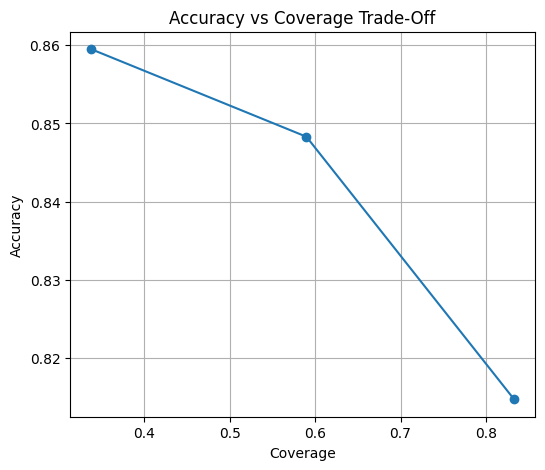

In [ ]:
import matplotlib.pyplot as plt

thresholds = [0.6, 0.7, 0.8]
coverage = [0.8328, 0.5898, 0.3380]
accuracy = [0.8147, 0.8483, 0.8595]

plt.figure(figsize=(6,5))
plt.plot(coverage, accuracy, marker='o')
plt.xlabel("Coverage")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Coverage Trade-Off")
plt.grid(True)
plt.savefig("accuracy_coverage_tradeoff.png", dpi=300, bbox_inches='tight')
plt.show()

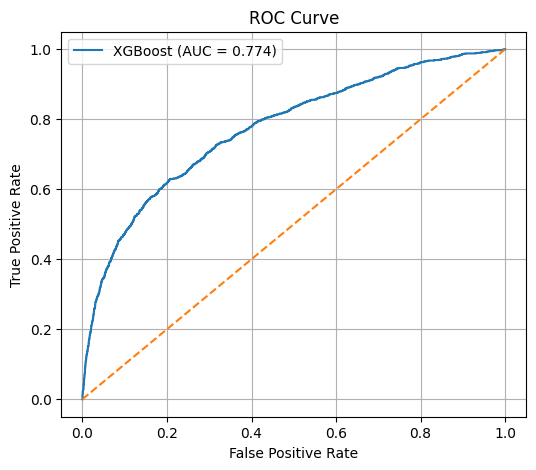

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

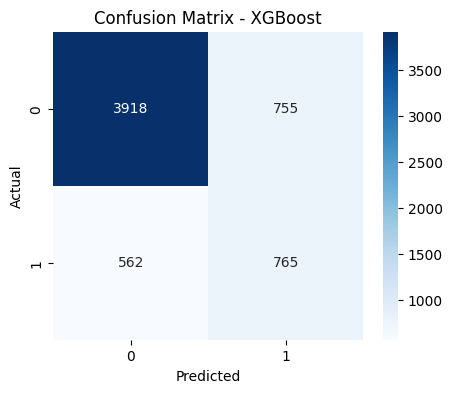

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

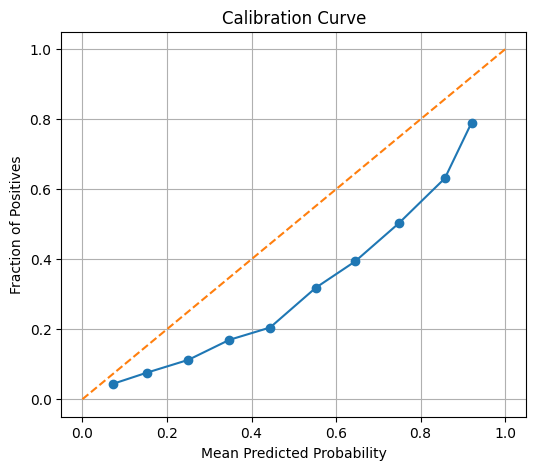

Brier Score: 0.16630393388038647


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.grid(True)
plt.savefig("calibration_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("Brier Score:", brier_score_loss(y_test, xgb_prob))

In [ ]:
from sklearn.model_selection import cross_val_score

# XGBoost model (same tuned version)
xgb_model_cv = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=3,
    eval_metric='logloss',
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model_cv,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("5-Fold CV AUC Scores:", cv_scores)
print("Mean AUC:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.show()


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [ ]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, xgb_prob)
print("Brier Score:", brier)


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

xgb = XGBClassifier(eval_metric='logloss')

grid = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best AUC:", grid.best_score_)


In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve - XGBoost")
plt.show()


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.savefig("calibration_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("Brier Score:", brier_score_loss(y_test, xgb_prob))

In [ ]:
print(type(X_train))
print(type(X_test))